#  Cell 1 — Libraries

In [1]:
# Task 8: Google Play Store Analysis
# Intern: Suraj Kumar | OIB/J2/IP2626

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


# Cell 2 — Data Loading

In [2]:
# Step 2: Data Loading
apps = pd.read_csv('apps.csv')
reviews = pd.read_csv('user_reviews.csv')

print("Apps Dataset:")
print("Shape:", apps.shape)
print("\nFirst 3 rows:")
print(apps.head(3))
print("\nUser Reviews Dataset:")
print("Shape:", reviews.shape)
print("\nFirst 3 rows:")
print(reviews.head(3))

Apps Dataset:
Shape: (9659, 14)

First 3 rows:
   Unnamed: 0                                                App  \
0           0     Photo Editor & Candy Camera & Grid & ScrapBook   
1           1                                Coloring book moana   
2           2  U Launcher Lite – FREE Live Cool Themes, Hide ...   

         Category  Rating  Reviews  Size    Installs  Type Price  \
0  ART_AND_DESIGN     4.1      159  19.0     10,000+  Free     0   
1  ART_AND_DESIGN     3.9      967  14.0    500,000+  Free     0   
2  ART_AND_DESIGN     4.7    87510   8.7  5,000,000+  Free     0   

  Content Rating                     Genres      Last Updated Current Ver  \
0       Everyone               Art & Design   January 7, 2018       1.0.0   
1       Everyone  Art & Design;Pretend Play  January 15, 2018       2.0.0   
2       Everyone               Art & Design    August 1, 2018       1.2.4   

    Android Ver  
0  4.0.3 and up  
1  4.0.3 and up  
2  4.0.3 and up  

User Reviews Dataset:
Sha

# Cell 3 — Data Cleaning

In [3]:
# Step 3: Data Cleaning
print("Missing Values in Apps:")
print(apps.isnull().sum())

# Drop unnecessary column
apps = apps.drop('Unnamed: 0', axis=1)

# Fill missing ratings
apps['Rating'] = apps['Rating'].fillna(apps['Rating'].mean())

# Clean Installs column
apps['Installs'] = apps['Installs'].str.replace(',', '').str.replace('+', '')
apps['Installs'] = pd.to_numeric(apps['Installs'], errors='coerce')

# Clean Price column
apps['Price'] = apps['Price'].astype(str).str.replace('$', '')
apps['Price'] = pd.to_numeric(apps['Price'], errors='coerce').fillna(0)

# Drop remaining missing values
apps = apps.dropna(subset=['Size', 'Android Ver'])

print("\nAfter Cleaning Shape:", apps.shape)
print("\nMissing Values After:")
print(apps.isnull().sum())

Missing Values in Apps:
Unnamed: 0           0
App                  0
Category             0
Rating            1463
Reviews              0
Size              1227
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

After Cleaning Shape: (8430, 13)

Missing Values After:
App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       8
Android Ver       0
dtype: int64


# Cell 4 — Category Analysis

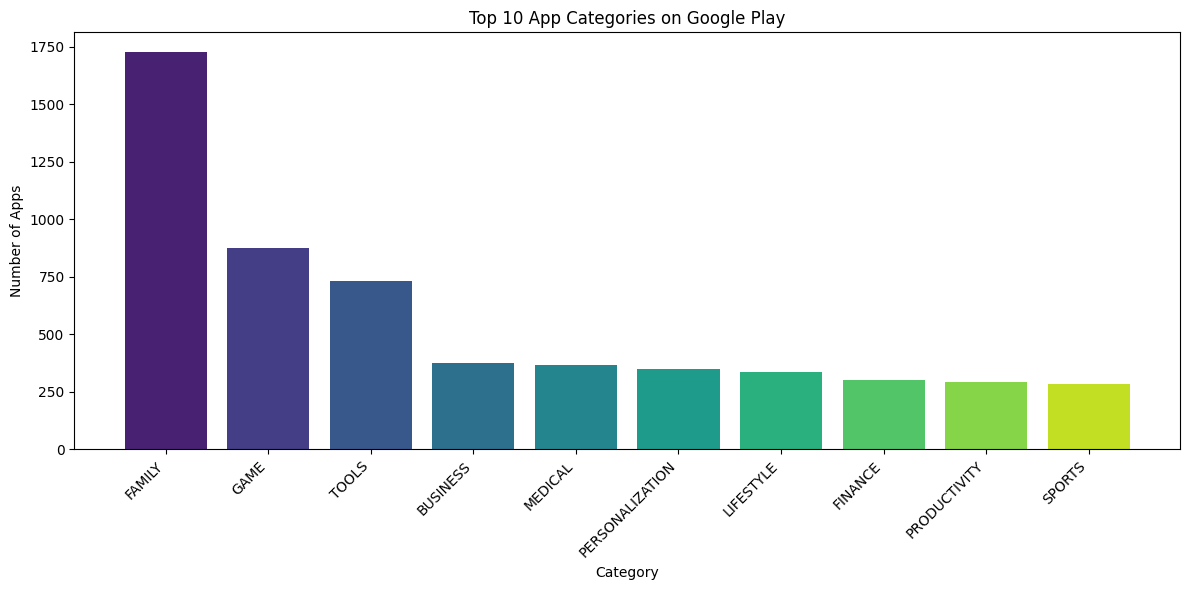

Top 10 Categories:
Category
FAMILY             1726
GAME                873
TOOLS               731
BUSINESS            376
MEDICAL             368
PERSONALIZATION     349
LIFESTYLE           334
FINANCE             299
PRODUCTIVITY        291
SPORTS              285
Name: count, dtype: int64


In [4]:
# Step 4: Category Exploration

# Graph 1 - Top 10 Categories
plt.figure(figsize=(12,6))
top_categories = apps['Category'].value_counts().head(10)
plt.bar(top_categories.index, top_categories.values,
        color=sns.color_palette('viridis', 10))
plt.title('Top 10 App Categories on Google Play')
plt.xlabel('Category')
plt.ylabel('Number of Apps')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 10 Categories:")
print(top_categories)

#  Cell 5 — Ratings & Type Analysis

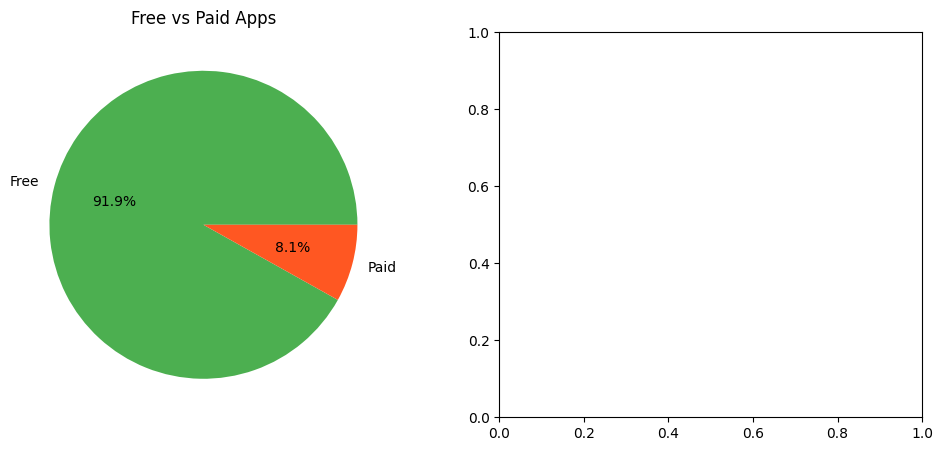

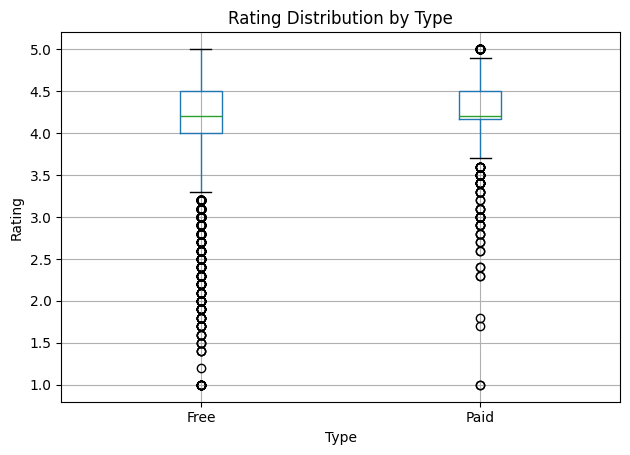

In [5]:
# Graph 2 - Free vs Paid Apps
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
type_counts = apps['Type'].value_counts()
plt.pie(type_counts.values, labels=type_counts.index,
        autopct='%1.1f%%', colors=['#4CAF50','#FF5722'])
plt.title('Free vs Paid Apps')

plt.subplot(1,2,2)
apps.boxplot(column='Rating', by='Type')
plt.title('Rating Distribution by Type')
plt.suptitle('')
plt.xlabel('Type')
plt.ylabel('Rating')

plt.tight_layout()
plt.show()

# Cell 6 — Sentiment Analysis

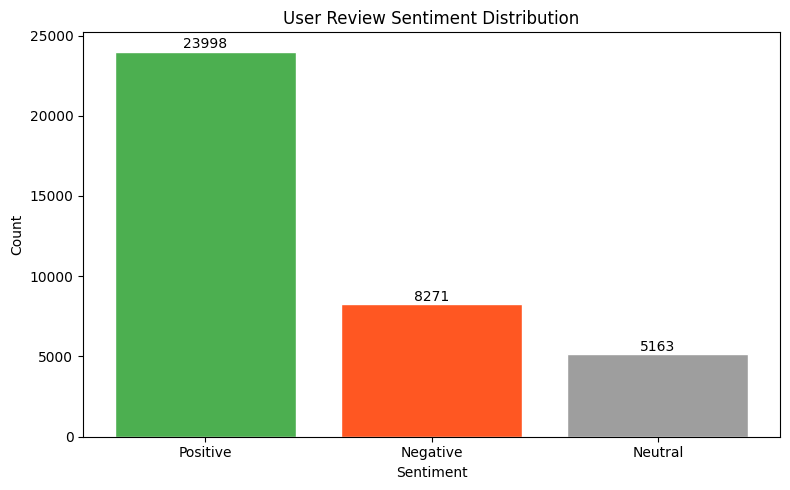

Sentiment Distribution:
Sentiment
Positive    23998
Negative     8271
Neutral      5163
Name: count, dtype: int64


In [6]:
# Step 5: Sentiment Analysis on Reviews

# Graph 3 - Sentiment Distribution
plt.figure(figsize=(8,5))
sentiment_counts = reviews['Sentiment'].value_counts()
colors = ['#4CAF50', '#FF5722', '#9E9E9E']
plt.bar(sentiment_counts.index, sentiment_counts.values,
        color=colors, edgecolor='white')
plt.title('User Review Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v + 200, str(v), ha='center')
plt.tight_layout()
plt.show()

print("Sentiment Distribution:")
print(sentiment_counts)

# Cell 7 — Recommendations

In [7]:
# Step 6: Insights & Recommendations
print("=" * 55)
print("GOOGLE PLAY STORE - INSIGHTS & RECOMMENDATIONS")
print("=" * 55)
print("""
KEY INSIGHTS:

1. TOP CATEGORIES
   - FAMILY apps dominate - 1,726 apps
   - GAME second - 873 apps
   - TOOLS third - 731 apps

2. FREE vs PAID
   - 91.9% apps are FREE
   - Free & Paid have similar ratings ~4.2

3. USER SENTIMENTS
   - Positive reviews: 23,998 (64.6%)
   - Negative reviews: 8,271 (22.3%)
   - Neutral reviews: 5,163 (13.9%)

4. APP RATINGS
   - Average rating: 4.2
   - Both Free & Paid apps rated similarly

RECOMMENDATIONS:
1. Focus on FAMILY & GAME categories
2. Keep apps FREE for more installs
3. Address negative reviews to improve ratings
4. Regular updates improve user satisfaction
""")
print("=" * 55)
print("Task 8 Complete! - Suraj Kumar | OIB/J2/IP2626")
print("=" * 55)

GOOGLE PLAY STORE - INSIGHTS & RECOMMENDATIONS

KEY INSIGHTS:

1. TOP CATEGORIES
   - FAMILY apps dominate - 1,726 apps
   - GAME second - 873 apps
   - TOOLS third - 731 apps

2. FREE vs PAID
   - 91.9% apps are FREE
   - Free & Paid have similar ratings ~4.2

3. USER SENTIMENTS
   - Positive reviews: 23,998 (64.6%)
   - Negative reviews: 8,271 (22.3%)
   - Neutral reviews: 5,163 (13.9%)

4. APP RATINGS
   - Average rating: 4.2
   - Both Free & Paid apps rated similarly

RECOMMENDATIONS:
1. Focus on FAMILY & GAME categories
2. Keep apps FREE for more installs
3. Address negative reviews to improve ratings
4. Regular updates improve user satisfaction

Task 8 Complete! - Suraj Kumar | OIB/J2/IP2626
